# Jamming State Analysis with Final-State High-Force Node Groups

This notebook is the jamming-specific version of the analysis workflow. It uses the corrected jamming graph list thresholded with the final-load `0deg` force threshold, but it does not run force-cluster extraction because that threshold creates no high-force jamming contacts.

Instead, jamming-state particle nodes are grouped by whether the same `geometry/sim_idx/node_id` particle is a high-force node in the final state. Edge analysis is kept aggregate because contacts are not stable objects across load states.

In [1]:
from pathlib import Path
import pickle
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("/scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim")
FINAL_GRAPH_DIR = ROOT / "AnalysisResults/FinalLoadState/FullGraph_2mean_ref_geom"
JAMMING_GRAPH_DIR = ROOT / "AnalysisResults/JammingState/FullGraph_final_load_threshold"
GROUP_DIR = ROOT / "AnalysisResults/JammingState/FinalForceNodeGroups"
POST_ANALYSIS_DIR = ROOT / "AnalysisScripts/post_analysis"
PLOT_DIR = GROUP_DIR / "Plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TRANSFER_SCRIPT = POST_ANALYSIS_DIR / "transfer_final_force_node_groups.py"

GEOM_ORDER = ["0deg", "15deg", "30deg", "45deg"]
GEOM_ANGLES = [0, 15, 30, 45]
GEOM_LABELS = ["0°", "15°", "30°", "45°"]

plt.rcParams["font.family"] = "Times New Roman"
print("Jamming graph dir:", JAMMING_GRAPH_DIR)
print("Transferred node-group dir:", GROUP_DIR)

Jamming graph dir: /scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/JammingState/FullGraph_final_load_threshold
Transferred node-group dir: /scratch/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/JammingState/FinalForceNodeGroups


## 1. Threshold and Graph Sanity Check

In [2]:
with open(FINAL_GRAPH_DIR / "high_force_threshold_info.pkl", "rb") as f:
    final_threshold_info = pickle.load(f)
with open(JAMMING_GRAPH_DIR / "high_force_threshold_info.pkl", "rb") as f:
    jamming_threshold_info = pickle.load(f)

hf_edges = pd.read_csv(JAMMING_GRAPH_DIR / "high_force_edges.csv")

print("Final threshold info:", final_threshold_info)
print("Corrected jamming threshold info:", jamming_threshold_info)
print("Corrected jamming high-force edge count:", len(hf_edges))
assert final_threshold_info["thresholds"]["0deg"] == jamming_threshold_info["thresholds"]["0deg"]

Final threshold info: {'mode': 'reference[0deg]', 'thresholds': {'0deg': 0.4200944651809045}}
Corrected jamming threshold info: {'mode': 'external_reference[FinalLoadState/0deg]', 'thresholds': {'0deg': 0.4200944651809045}, 'source': '/gpfs/accounts/abucsek_root/abucsek0/yfjin/Granular_RubySim/AnalysisResults/FinalLoadState/FullGraph_2mean_ref_geom'}
Corrected jamming high-force edge count: 0


In [3]:
with open(JAMMING_GRAPH_DIR / "graph_dict_labeled.pkl", "rb") as f:
    GL_jamming = pickle.load(f)

print("Jamming graph geometries:", list(GL_jamming.keys()))
for geom in GEOM_ORDER:
    if geom in GL_jamming:
        print(geom, {view: len(GL_jamming[geom][view]) for view in ["core", "full"]})

Jamming graph geometries: ['0deg', '15deg', '30deg', '45deg']
0deg {'core': 20, 'full': 20}
15deg {'core': 20, 'full': 20}
30deg {'core': 20, 'full': 20}
45deg {'core': 20, 'full': 20}


## 2. Build or Load Node Groups Transferred from Final State

In [4]:
required_files = [
    GROUP_DIR / "jamming_node_features_with_final_force_labels.csv",
    GROUP_DIR / "jamming_node_stats_by_final_force_group.csv",
]

if not all(path.exists() for path in required_files):
    print("Transferred node-group tables are missing; generating them now...")
    subprocess.run([sys.executable, str(TRANSFER_SCRIPT)], check=True)

node_groups = pd.read_csv(GROUP_DIR / "jamming_node_features_with_final_force_labels.csv")
node_stats = pd.read_csv(GROUP_DIR / "jamming_node_stats_by_final_force_group.csv")

print("node_groups:", node_groups.shape)
print("node_stats:", node_stats.shape)
node_groups.head()

node_groups: (37120, 40)
node_stats: (360, 7)


,geometry,sim_idx,node_id,x,y,z,is_wall,in_center_region,stress_11,stress_22,...,nfd,nfd_r2,principal_eigenvector_with_walls,fiedler_with_walls,high_force_degree,is_force_chain_node,force_chain_role,final_high_force_degree,final_is_force_chain_node,final_force_chain_role
0,0deg,0,0,0.000824,0.000295,0.005925,False,False,-1.283754e-11,-1.389833e-10,...,2.102275,0.986526,0.048913,0.044506,0,False,none,0,False,none
1,0deg,0,1,0.000891,0.000858,0.005925,False,False,-2.166831e-10,-2.266999e-10,...,2.179067,0.978533,0.031132,-0.013797,0,False,none,0,False,none
2,0deg,0,2,0.000291,0.000255,0.005925,False,False,-1.344000e-10,-1.384124e-10,...,2.062756,0.989214,0.032992,0.059278,0,False,none,1,True,endpoint
3,0deg,0,3,0.000392,0.000908,0.005925,False,False,-1.034559e-10,-2.702867e-10,...,1.889984,0.976210,0.037801,0.008864,0,False,none,0,False,none
4,0deg,0,4,0.000773,0.000683,0.005925,False,False,-2.238895e-10,-1.434346e-10,...,2.229141,0.983853,0.038234,0.009663,0,False,none,0,False,none


In [5]:
label_counts = (
    node_groups.groupby(["geometry", "final_is_force_chain_node"])
    .size()
    .rename("n_nodes")
    .reset_index()
)
label_counts

,geometry,final_is_force_chain_node,n_nodes
0,0deg,False,5824
1,0deg,True,3456
2,15deg,False,6024
3,15deg,True,3256
4,30deg,False,5608
5,30deg,True,3672
6,45deg,False,5754
7,45deg,True,3526


## 3. Jamming Node Property Means

The values are measured at jamming. The grouping variable is transferred from the final state: `final_high_force`, `final_non_high_force`, or `all`.

In [6]:
FEATURES = [
    "stress_vm", "stress_hydro", "stress_33",
    "degree", "closeness", "betweenness", "clustering",
    "avg_neighbor_degree", "avg_curvature_no_walls",
    "nfd", "nfd_r2",
]

summary = (
    node_stats
    .query("feature in @FEATURES")
    .sort_values(["feature", "geometry", "group"])
)
summary[["geometry", "feature", "group", "mean", "stderr", "n"]]

,geometry,feature,group,mean,stderr,n
84,0deg,avg_curvature_no_walls,all,-1.966999e-01,1.370059e-03,9280
24,0deg,avg_curvature_no_walls,final_high_force,-1.818140e-01,2.433271e-03,3456
54,0deg,avg_curvature_no_walls,final_non_high_force,-2.055333e-01,1.626476e-03,5824
174,15deg,avg_curvature_no_walls,all,-2.042639e-01,1.185984e-03,9280
114,15deg,avg_curvature_no_walls,final_high_force,-1.936120e-01,2.065722e-03,3256
...,...,...,...,...,...,...
189,30deg,stress_vm,final_high_force,2.459605e-10,7.539947e-12,3672
219,30deg,stress_vm,final_non_high_force,1.780073e-10,4.054657e-12,5608
339,45deg,stress_vm,all,2.070003e-10,3.508344e-12,9280
279,45deg,stress_vm,final_high_force,2.387166e-10,6.398867e-12,3526


In [7]:
# Difference in jamming means: particles that are high-force at final state minus those that are not.
wide_group_means = (
    node_stats[node_stats["group"].isin(["final_high_force", "final_non_high_force"])]
    .pivot_table(index=["geometry", "feature"], columns="group", values="mean")
    .reset_index()
)
wide_group_means["mean_difference_high_minus_non"] = (
    wide_group_means["final_high_force"] - wide_group_means["final_non_high_force"]
)
wide_group_means.to_csv(GROUP_DIR / "jamming_node_mean_difference_final_high_minus_non.csv", index=False)
wide_group_means.query("feature in @FEATURES").sort_values(["feature", "geometry"])

group,geometry,feature,final_high_force,final_non_high_force,mean_difference_high_minus_non
0,0deg,avg_curvature_no_walls,-1.818140e-01,-2.055333e-01,2.371927e-02
30,15deg,avg_curvature_no_walls,-1.936120e-01,-2.100214e-01,1.640935e-02
60,30deg,avg_curvature_no_walls,-1.807984e-01,-1.860503e-01,5.251902e-03
90,45deg,avg_curvature_no_walls,-1.873527e-01,-1.911621e-01,3.809403e-03
2,0deg,avg_neighbor_degree,4.447153e+00,4.608873e+00,-1.617200e-01
32,15deg,avg_neighbor_degree,4.569063e+00,4.728824e+00,-1.597609e-01
62,30deg,avg_neighbor_degree,4.435835e+00,4.503150e+00,-6.731545e-02
92,45deg,avg_neighbor_degree,4.411068e+00,4.429382e+00,-1.831400e-02
4,0deg,betweenness,1.027733e-02,1.327727e-02,-2.999941e-03
34,15deg,betweenness,1.083216e-02,1.322560e-02,-2.393448e-03


## 4. Mean Property Plots

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

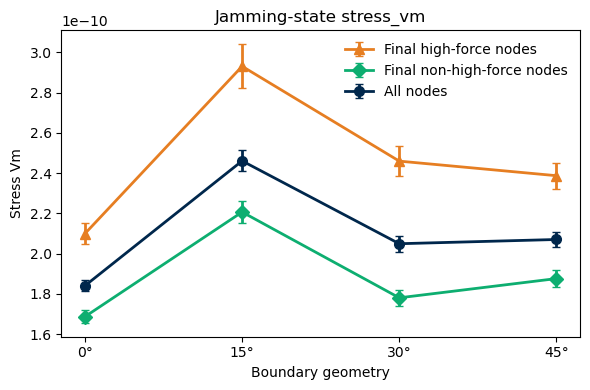

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

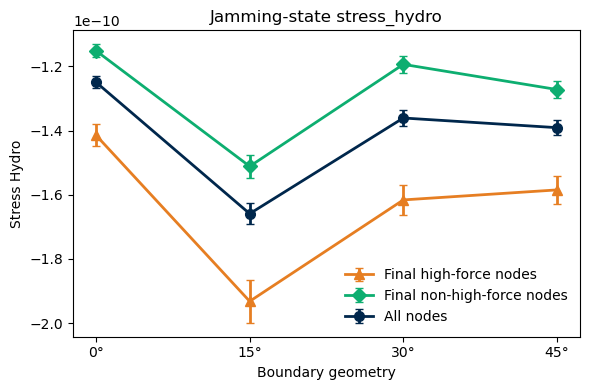

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

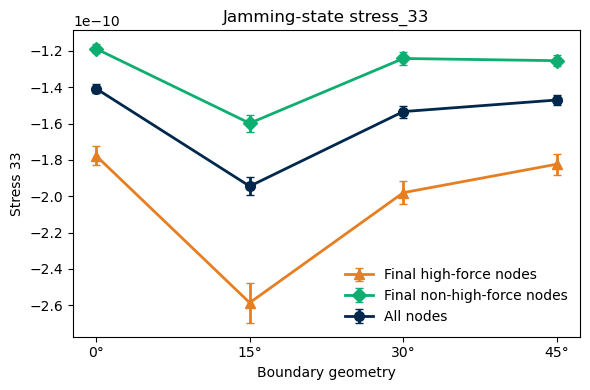

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

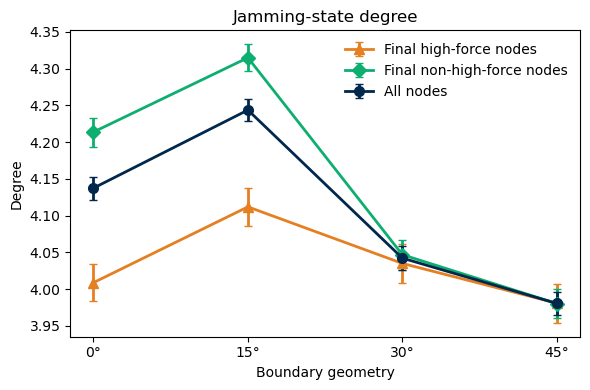

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

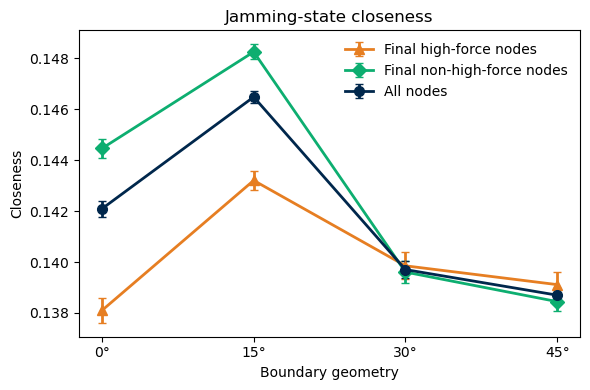

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

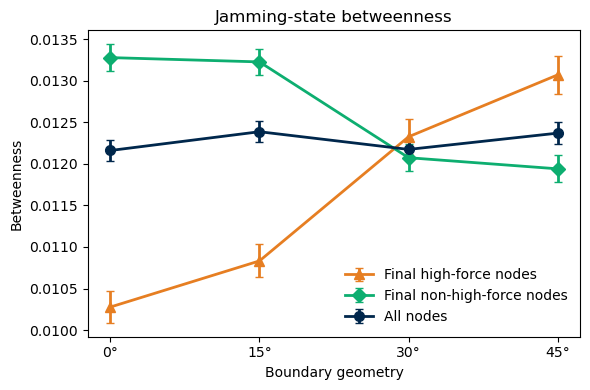

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

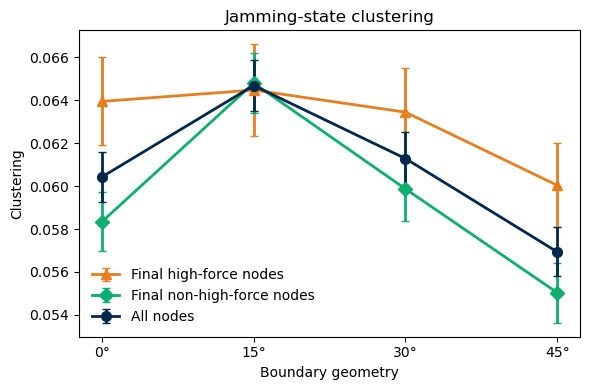

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

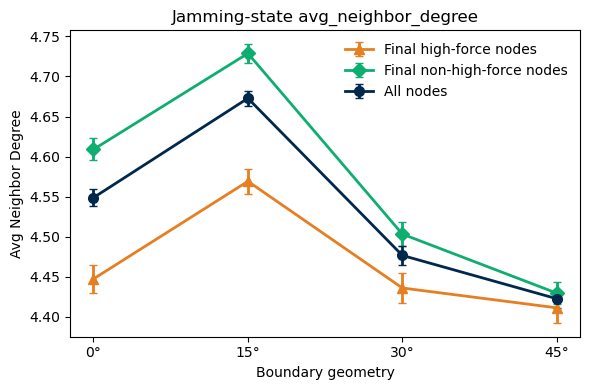

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

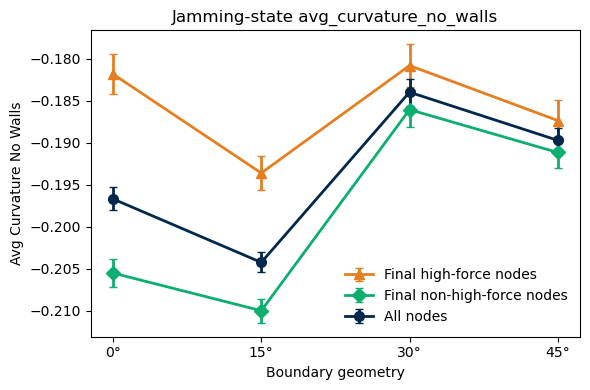

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

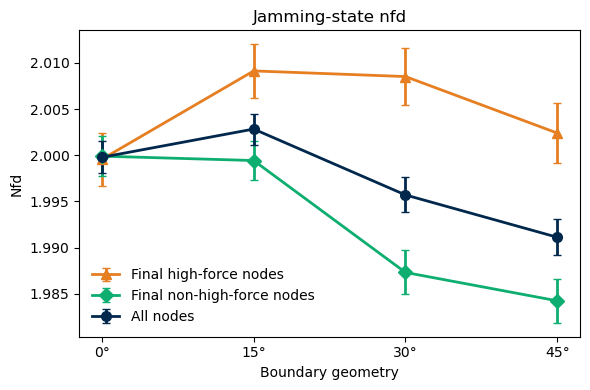

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

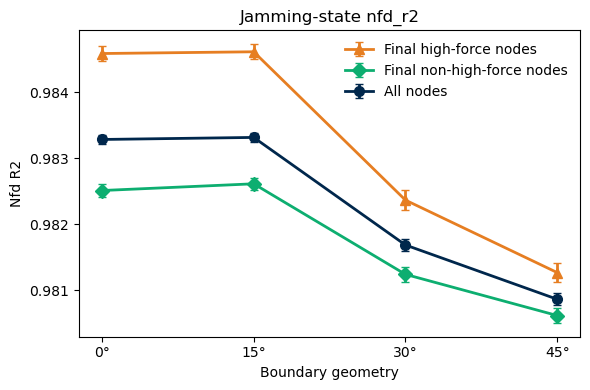

In [8]:
GROUP_STYLES = {
    "final_high_force": {"label": "Final high-force nodes", "color": "#E67E22", "marker": "^"},
    "final_non_high_force": {"label": "Final non-high-force nodes", "color": "#0DAE70", "marker": "D"},
    "all": {"label": "All nodes", "color": "#00274C", "marker": "o"},
}

def plot_feature_mean(feature, save=True):
    fig, ax = plt.subplots(figsize=(6, 4))
    for group, style in GROUP_STYLES.items():
        sub = node_stats[(node_stats["feature"] == feature) & (node_stats["group"] == group)]
        row = sub.set_index("geometry").reindex(GEOM_ORDER)
        ax.errorbar(
            GEOM_ANGLES, row["mean"], yerr=row["stderr"],
            color=style["color"], marker=style["marker"], linewidth=2,
            markersize=7, capsize=3, label=style["label"],
        )
    ax.set_xticks(GEOM_ANGLES)
    ax.set_xticklabels(GEOM_LABELS)
    ax.set_xlabel("Boundary geometry")
    ax.set_ylabel(feature.replace("_", " ").title())
    ax.set_title(f"Jamming-state {feature}")
    ax.legend(frameon=False)
    fig.tight_layout()
    if save:
        fig.savefig(PLOT_DIR / f"jamming_{feature}_by_final_force_node_group.png", dpi=250, bbox_inches="tight")
    return fig, ax

for feature in FEATURES:
    plot_feature_mean(feature)
    plt.show()

## 5. Saved Loop Metrics at Jamming

In [9]:
LOOP_GRAPH_VIEW = "core"
suffix = "_with_walls" if LOOP_GRAPH_VIEW == "full" else ""
loop_sizes_key = f"loop_sizes{suffix}"
loop_counts_key = f"loop_counts{suffix}"
loop_total_key = f"loop_total{suffix}"
loop_mean_key = f"loop_mean{suffix}"

def expand_saved_loop_sizes(graph_attrs, sizes_key, counts_key):
    sizes = graph_attrs.get(sizes_key)
    if sizes is not None:
        return [int(s) for s in sizes]
    counts = graph_attrs.get(counts_key, {}) or {}
    expanded = []
    for size, count in sorted(counts.items(), key=lambda kv: int(kv[0])):
        expanded.extend([int(size)] * int(count))
    return expanded

loop_records = []
for geom in GEOM_ORDER:
    for sim_idx, G in enumerate(GL_jamming[geom][LOOP_GRAPH_VIEW]):
        arr = np.asarray(expand_saved_loop_sizes(G.graph, loop_sizes_key, loop_counts_key), dtype=int)
        loop_records.append({
            "geometry": geom,
            "sim_idx": sim_idx,
            "loop_total": int(G.graph.get(loop_total_key, len(arr))),
            "loop_mean": float(G.graph.get(loop_mean_key, np.mean(arr) if arr.size else np.nan)),
            "triangle_fraction": float(np.sum(arr == 3) / len(arr)) if arr.size else np.nan,
        })

loop_df = pd.DataFrame(loop_records)
loop_summary = loop_df.groupby("geometry").agg(
    n_sims=("sim_idx", "size"),
    mean_loop_total=("loop_total", "mean"),
    stderr_loop_total=("loop_total", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
    mean_loop_mean=("loop_mean", "mean"),
    mean_triangle_fraction=("triangle_fraction", "mean"),
).reset_index()
loop_df.to_csv(GROUP_DIR / "jamming_loop_metrics_per_sim.csv", index=False)
loop_summary.to_csv(GROUP_DIR / "jamming_loop_metrics_summary.csv", index=False)
loop_summary

,geometry,n_sims,mean_loop_total,stderr_loop_total,mean_loop_mean,mean_triangle_fraction
0,0deg,20,506.35,18.444979,4.518214,0.150374
1,15deg,20,525.30,6.661002,4.458812,0.159883
2,30deg,20,486.55,23.801755,4.578102,0.152175
3,45deg,20,471.00,11.951217,4.544694,0.152544


## 6. Aggregate Edge Properties at Jamming

In [10]:
edge_features = pd.read_csv(JAMMING_GRAPH_DIR / "edge_features.csv")
edge_numeric = [
    c for c in edge_features.columns
    if c not in {"sim_idx", "node1", "node2"}
    and not pd.api.types.is_bool_dtype(edge_features[c])
    and pd.api.types.is_numeric_dtype(edge_features[c])
]

edge_summary = (
    edge_features.groupby("geometry")[edge_numeric]
    .agg(["mean", "std", "count"])
)
edge_summary.to_csv(GROUP_DIR / "jamming_edge_property_summary.csv")
edge_summary.head()

contact_x                  contact_y                  contact_z  \
              mean       std  count      mean       std  count      mean   
geometry                                                                   
0deg      0.000752  0.000376  23425  0.000745  0.000374  23425  0.005615   
15deg     0.000753  0.000373  23877  0.000756  0.000373  23877  0.005667   
30deg     0.000751  0.000369  22797  0.000753  0.000369  22797  0.005730   
45deg     0.000748  0.000367  22851  0.000749  0.000364  22851  0.005815   

                                  delta  ... node_connectivity  \
               std  count          mean  ...             count   
geometry                                 ...                     
0deg      0.000230  23425  1.281839e-09  ...             19197   
15deg     0.000230  23877  1.449287e-09  ...             19690   
30deg     0.000234  22797  1.340378e-09  ...             18755   
45deg     0.000245  22851  1.370558e-09  ...             18469   

         node_connectivity_with_walls                  curvature_with_walls  \
                                 mean       std  count                 mean   
geometry                                                                      
0deg                         3.947909  1.109308  19197            -0.290297   
15deg                        3.979279  1.091468  19690            -0.291403   
30deg                        3.889469  1.139653  18755            -0.287119   
45deg                        3.826033  1.148825  18469            -0.295768   

                          curvature_no_walls                   
               std  count               mean       std  count  
geometry                                                       
0deg      0.145449  19197          -0.220989  0.156041  19197  
15deg     0.138176  19690          -0.222424  0.151883  19690  
30deg     0.151731  18755          -0.216371  0.167652  18755  
45deg     0.150399  18469          -0.220099  0.162851  18469  

[4 rows x 60 columns]

## 7. Why Edges Are Not Grouped by Final High-Force Labels

Nodes are trackable because particle ids are stable between jamming and final state. Edges represent contacts. Contacts can appear, disappear, or change partners across load states, and the current tables do not have a stable contact id.

A conservative edge comparison is aggregate by geometry/simulation. If you later want matched-edge analysis, the least risky rule is to match only edges with the same unordered particle-pair `(node1, node2)` present in both states, while excluding wall contacts unless you define wall identity carefully.